In [1]:
import os
hf_token = os.getenv("HF_TOKEN")

import re

from sklearn.model_selection import train_test_split
import gensim.downloader     #na nacitanie predtrenovaneho word2vec modelu
from nltk.tokenize import word_tokenize
import nltk     #natural language processing
nltk.download('punkt', quiet=True)

from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec
from transformers import AutoTokenizer, AutoModel
import torch

from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple
from src.ML.train_rf import train_random_forest
from src.data_loader import load_data

In [2]:
# Load your dataset
df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")

Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained BERT model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 694 entries.
Embeddings created. Shape: (555, 384)
Categories:
 Category
0    0.727928
1    0.272072
Name: proportion, dtype: float64

RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (555, 384)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[-0.0981397   0.12419126 -0.32490024  0.06120977 -0.34975445  0.0631097
  0.27390516 -0.24072687  0.10196473 -0.18389593]
------------------------------
Original class weights: [0.68688119 1.83774834]
Boosted class weights: [0.68688119 

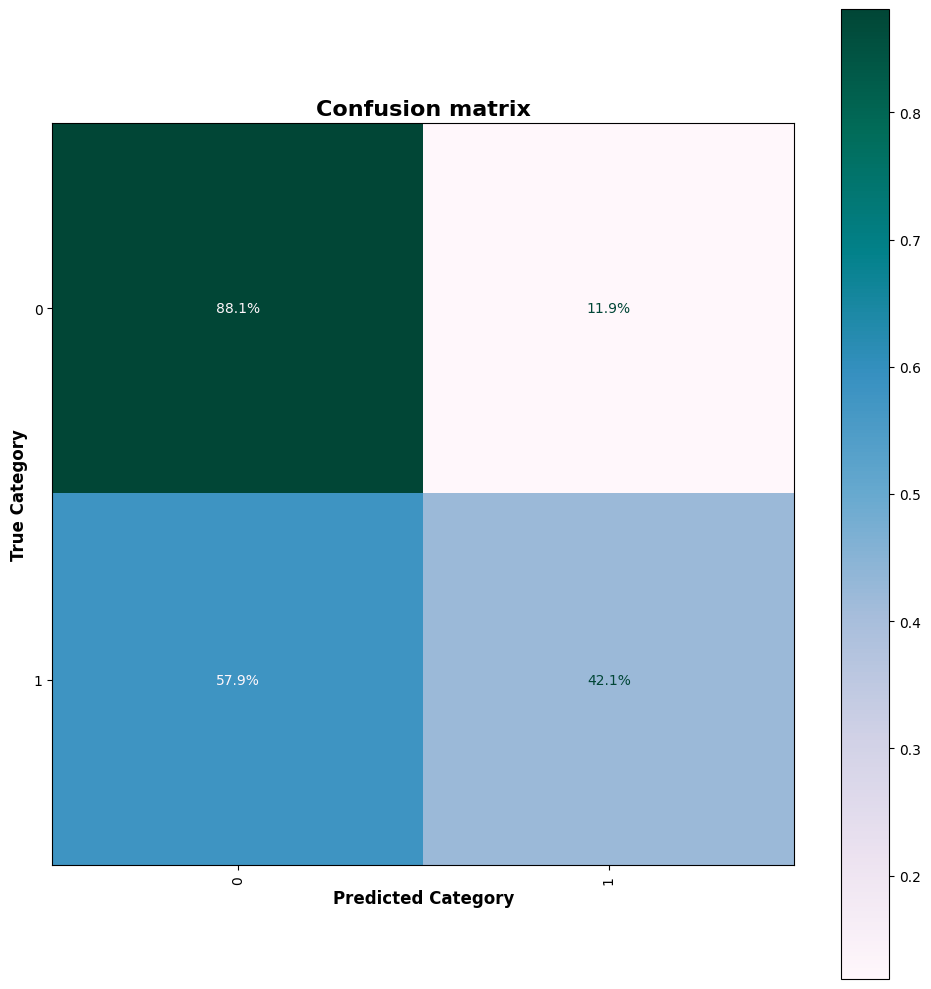

<Figure size 640x480 with 0 Axes>

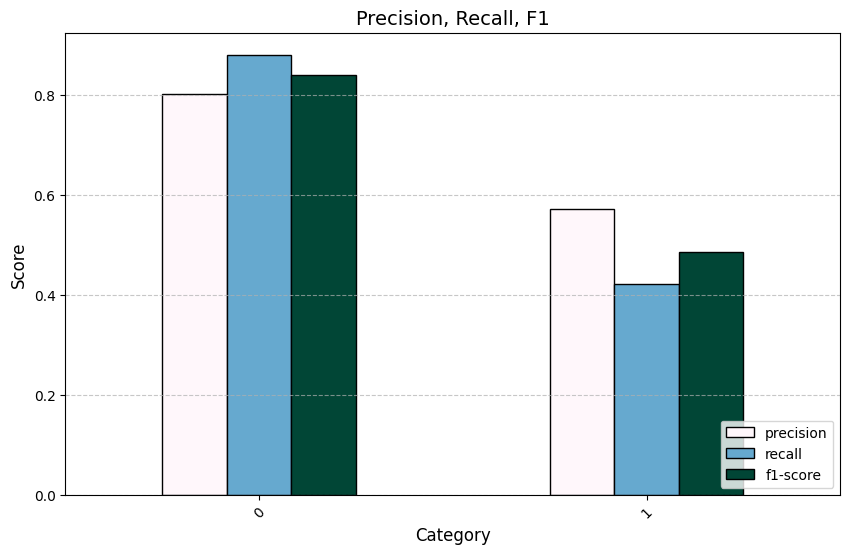

<Figure size 640x480 with 0 Axes>

In [3]:
# pocetnost kategorii
print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda" if torch.cuda.is_available() else "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)

minilm_model.eval()  # set to evaluation mode

# Convert text to BERT embeddings
X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

print("Embeddings created. Shape:", X_train_vec.shape)
print("Categories:\n", y_train.value_counts(normalize=True))

target_names = [str(t) for t in sorted(y_train.unique())]



rf_model = train_random_forest(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 3.0)

In [ ]:
# pocetnost kategorii
from src.ML import train_SVM


print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda" if torch.cuda.is_available() else "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)

minilm_model.eval()  # set to evaluation mode

# Convert text to BERT embeddings
X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

print("Embeddings created. Shape:", X_train_vec.shape)
print("Categories:\n", y_train.value_counts(normalize=True))

target_names = [str(t) for t in sorted(y_train.unique())]



svm_model = train_SVM(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 3.0)

Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained BERT model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 694 entries.
Embeddings created. Shape: (555, 384)
Categories:
 Category
0    0.727928
1    0.272072
Name: proportion, dtype: float64


TypeError: 'module' object is not callable